# Full Sonar/DSP Processing Pipeline Demo

This notebook demonstrates a realistic end-to-end sonar/DSP signal processing pipeline using the utilities you've built.

---

## Pipeline Steps
1. **Generate**: Create a synthetic sonar pulse plus noise
2. **Filter**: Apply a bandpass FIR filter to clean up the signal
3. **Envelope Detection**: Use the Hilbert transform to extract amplitude envelope
4. **Peak Detection**: Find pulse arrival(s) or event(s)
5. **Frequency Analysis**: FFT & spectrogram for time-frequency content
6. **ROC Analysis**: Evaluate detection performance (if desired)

Each step uses the utils in your library—adapt for real data as needed!
---


## Step 1: Generate Synthetic Sonar Pulse + Noise

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.signal import chirp, spectrogram


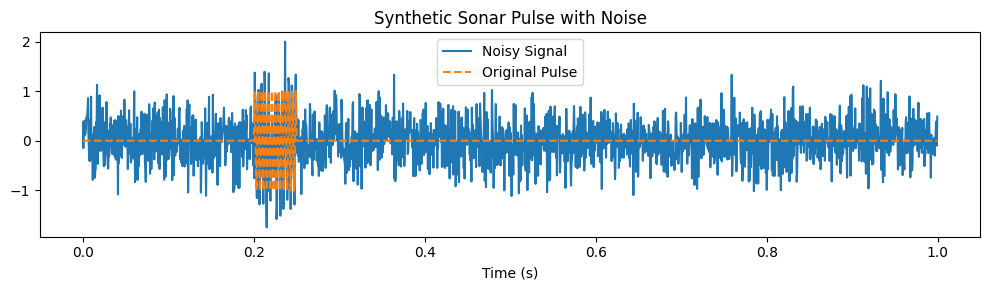

In [2]:
fs = 2000
t = np.arange(0, 1.0, 1/fs)
pulse = np.sin(2*np.pi*250*t) * (t > 0.2) * (t < 0.25)  # Pulse at t=0.2-0.25s
noise = 0.4 * np.random.randn(len(t))
signal = pulse + noise

plt.figure(figsize=(10,3))
plt.plot(t, signal, label='Noisy Signal')
plt.plot(t, pulse, '--', label='Original Pulse')
plt.legend()
plt.title('Synthetic Sonar Pulse with Noise')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()


## Step 2: Filter Signal (Bandpass FIR)

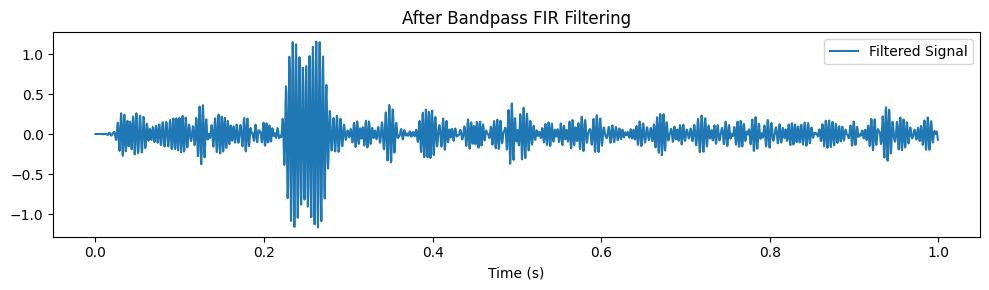

In [3]:
from scipy.signal import firwin, lfilter

def fir_bandpass(signal, fs, lowcut, highcut, numtaps=101):
    taps = firwin(numtaps, [lowcut, highcut], pass_zero=False, fs=fs)
    return lfilter(taps, 1.0, signal)

filtered = fir_bandpass(signal, fs, lowcut=200, highcut=300)

plt.figure(figsize=(10,3))
plt.plot(t, filtered, label='Filtered Signal')
plt.legend()
plt.title('After Bandpass FIR Filtering')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()


## Step 3: Envelope Detection (Hilbert Transform)

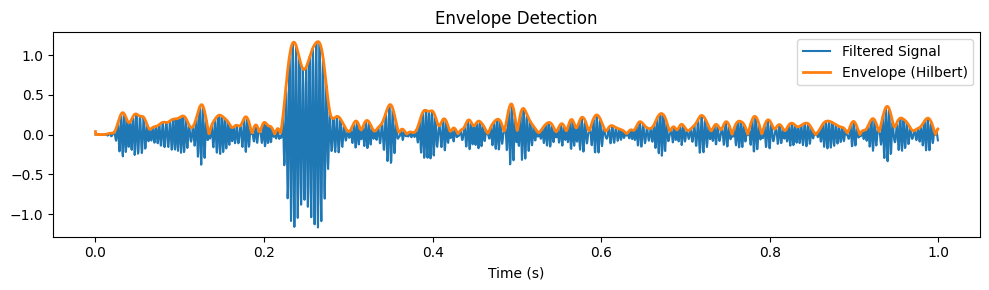

In [4]:
analytic = hilbert(filtered)
envelope = np.abs(analytic)

plt.figure(figsize=(10,3))
plt.plot(t, filtered, label='Filtered Signal')
plt.plot(t, envelope, label='Envelope (Hilbert)', lw=2)
plt.legend()
plt.title('Envelope Detection')
plt.xlabel('Time (s)')
plt.tight_layout()
plt.show()


## Step 4: Peak Detection

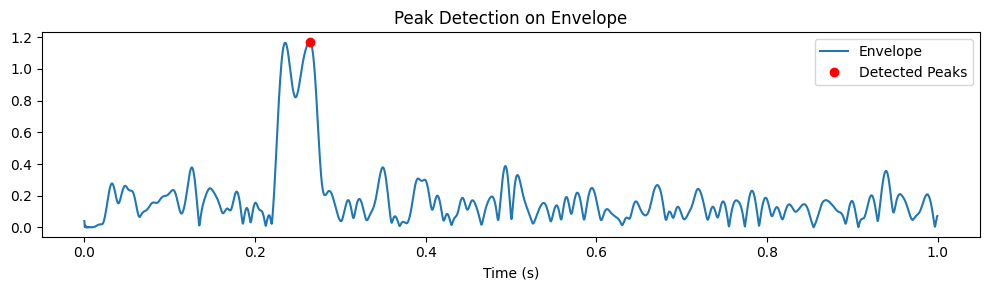

Detected pulse(s) at: [264.] ms


In [5]:
from scipy.signal import find_peaks

peaks, props = find_peaks(envelope, height=0.5, distance=fs//20)
plt.figure(figsize=(10,3))
plt.plot(t, envelope, label='Envelope')
plt.plot(t[peaks], envelope[peaks], 'ro', label='Detected Peaks')
plt.title('Peak Detection on Envelope')
plt.xlabel('Time (s)')
plt.legend()
plt.tight_layout()
plt.show()
print(f"Detected pulse(s) at: {t[peaks]*1000} ms")

## Step 5: Frequency Analysis (FFT & Spectrogram)

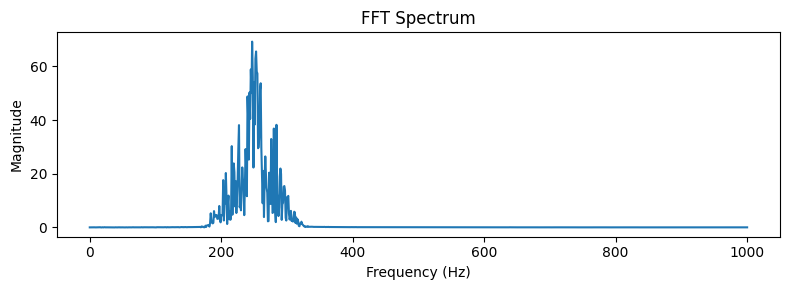

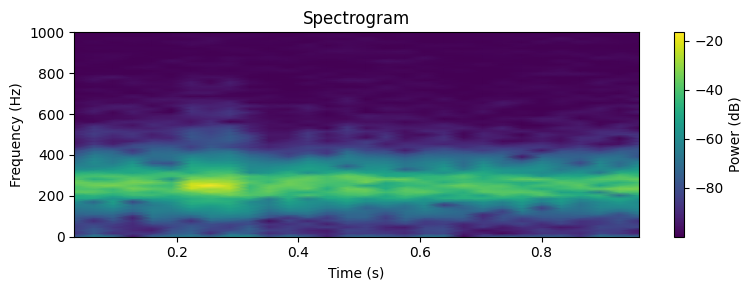

In [6]:
freqs = np.fft.rfftfreq(len(filtered), 1/fs)
fft_vals = np.abs(np.fft.rfft(filtered))

plt.figure(figsize=(8,3))
plt.plot(freqs, fft_vals)
plt.title('FFT Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

f, tt, Sxx = spectrogram(filtered, fs, nperseg=128, noverlap=64)
plt.figure(figsize=(8,3))
plt.pcolormesh(tt, f, 10*np.log10(Sxx+1e-10), shading='gouraud')
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.title('Spectrogram')
plt.colorbar(label='Power (dB)')
plt.tight_layout()
plt.show()


## Step 6: ROC Analysis (Optional Example)

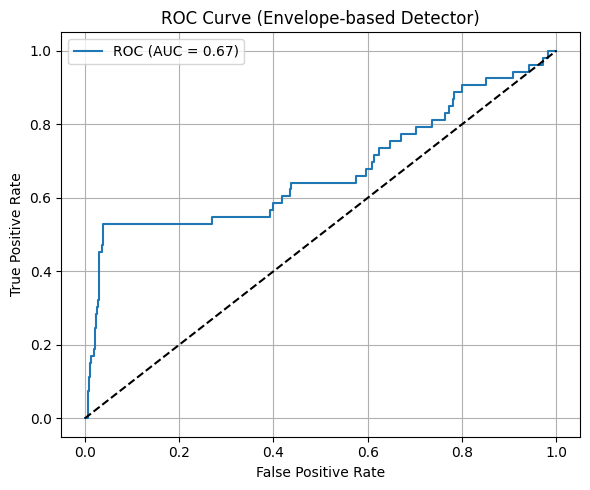

In [7]:
# Let's pretend envelope > 0.5 is our detector output; pulse is 'target' region
labels = (pulse > 0).astype(int)
scores = envelope
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(labels, scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Envelope-based Detector)')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


---
## Summary

- Swap in real signals or parameters for your use-case.
- Each step can be replaced with the corresponding utility from your `utils` folder.
- Show this end-to-end pipeline in interviews, README, or your portfolio for maximum impact!

**This notebook is the "glue" showing your mastery of the full DSP workflow.**
